# 02. Предобработка текста

Цель: подготовить два варианта текста для downstream-задач:

- **Pipeline A (`text_clean`)**: минимальная очистка (без лемматизации). Используется как вход для sentence-transformers при построении эмбеддингов. Модели типа SBERT обучены на живом тексте и лемматизация ухудшает качество

- **Pipeline B (`text_lemm`)**: очистка + токенизация (razdel) + лемматизация (pymorphy3). Используется для c-TF-IDF внутри BERTopic при построении представлений тем.

Фильтрация: удаляем посты короче 50 символов (1% датасета, выявлено в EDA `01_eda.ipynb`)

In [ ]:
import re
import os
import pandas as pd
from joblib import Parallel, delayed
import pymorphy3
import razdel
from tqdm import tqdm

In [2]:
RANDOM_STATE = 42
N_JOBS = 4

In [3]:
raw_df = pd.read_parquet("data/raw/posts.parquet", engine="fastparquet")

In [4]:
MIN_TEXT_LEN = 50
df = raw_df[raw_df["text"].fillna("").str.len() >= MIN_TEXT_LEN].copy()
df = df.reset_index(drop=True)

print(f"До фильтрации: {len(raw_df):,}")
print(f"После фильтрации: {len(df):,}")
print(
    f"Отфильтровано: {len(raw_df) - len(df):,} ({(len(raw_df) - len(df)) / len(raw_df) * 100:.1f}%)"
)

До фильтрации: 3,035,065
После фильтрации: 3,003,217
Отфильтровано: 31,848 (1.0%)


## Pipeline A - Очистка текста для эмбеддингов (`text_clean`)

Удаляем шум, который не несёт семантической нагрузки:
- URL
- Эмодзи и спецсимволы
- Markdown-разметку (`**bold**`, `_italic_`)
- Множественные пробелы

Лемматизацию **не применяем**. трансформерные модели работают лучше с естественным текстом

In [5]:
# Паттерны для очистки
_URL_RE = re.compile(r"https?://\S+|www\.\S+")
_EMOJI_RE = re.compile(
    "[\U00010000-\U0010ffff"
    "\U0001f600-\U0001f64f"
    "\U0001f300-\U0001f5ff"
    "\U0001f680-\U0001f6ff"
    "\U0001f1e0-\U0001f1ff"
    "\u2600-\u26ff\u2700-\u27bf]+",
    flags=re.UNICODE,
)
_MD_RE = re.compile(r"[*_`#|>\[\]~]")
_SPACES_RE = re.compile(r"\s+")


def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = _URL_RE.sub(" ", text)
    text = _EMOJI_RE.sub(" ", text)
    text = _MD_RE.sub(" ", text)
    text = _SPACES_RE.sub(" ", text)
    return text.strip()


# Быстрый тест
examples = [
    "Трамп поблагодарил Иран 🙏 за предупреждение https://t.me/example **важно**",
    "Просто обычный текст новости без мусора",
    "www.rbc.ru/link_to_article #тег _курсив_",
]
for ex in examples:
    print(f"До:    {ex}")
    print(f"После: {clean_text(ex)}")
    print()

До:    Трамп поблагодарил Иран 🙏 за предупреждение https://t.me/example **важно**
После: Трамп поблагодарил Иран за предупреждение важно

До:    Просто обычный текст новости без мусора
После: Просто обычный текст новости без мусора

До:    www.rbc.ru/link_to_article #тег _курсив_
После: тег курсив



## Pipeline B - Лемматизация для c-TF-IDF (`text_lemm`)

Поверх Pipeline A применяем:
1. **razdel** - токенизация с учётом особенностей русского текста
2. **pymorphy3** - лемматизация (приведение к начальной форме)
3. Фильтрация, оставляем только слова длиной ≥ 3 символа, удаляем стоп-слова и числа

razdel корректно разбивает текст на токены, pymorphy3 приводит каждый токен к нормальной форме

In [6]:
STOPWORDS = {
    "и",
    "в",
    "во",
    "не",
    "что",
    "он",
    "на",
    "я",
    "с",
    "со",
    "как",
    "а",
    "то",
    "все",
    "она",
    "так",
    "его",
    "но",
    "да",
    "ты",
    "к",
    "у",
    "же",
    "вы",
    "за",
    "бы",
    "по",
    "только",
    "ее",
    "мне",
    "было",
    "вот",
    "от",
    "меня",
    "еще",
    "нет",
    "о",
    "из",
    "ему",
    "теперь",
    "когда",
    "даже",
    "ну",
    "вдруг",
    "ли",
    "если",
    "уже",
    "или",
    "ни",
    "быть",
    "был",
    "него",
    "до",
    "вас",
    "нибудь",
    "опять",
    "уж",
    "вам",
    "ведь",
    "там",
    "потом",
    "себя",
    "ничего",
    "ей",
    "может",
    "они",
    "тут",
    "где",
    "есть",
    "надо",
    "ней",
    "для",
    "мы",
    "тебя",
    "их",
    "чем",
    "была",
    "сам",
    "чтоб",
    "без",
    "будто",
    "человек",
    "чего",
    "раз",
    "тоже",
    "себе",
    "под",
    "будет",
    "ж",
    "тогда",
    "кто",
    "этот",
    "того",
    "потому",
    "этого",
    "какой",
    "совсем",
    "ним",
    "здесь",
    "этом",
    "один",
    "почти",
    "мой",
    "тем",
    "чтобы",
    "нее",
    "сейчас",
    "были",
    "куда",
    "зачем",
    "всех",
    "никогда",
    "можно",
    "при",
    "наконец",
    "два",
    "об",
    "другой",
    "хоть",
    "после",
    "над",
    "больше",
    "тот",
    "через",
    "эти",
    "нас",
    "про",
    "всего",
    "них",
    "какая",
    "много",
    "разве",
    "три",
    "эту",
    "моя",
    "впрочем",
    "хорошо",
    "свою",
    "этой",
    "перед",
    "иногда",
    "лучше",
    "чуть",
    "том",
    "нельзя",
    "такой",
    "им",
    "более",
    "всегда",
    "конечно",
    "всю",
    "между",
}


def lemmatize_text(text: str, morph: pymorphy3.MorphAnalyzer) -> str:
    """Pipeline B: clean -> tokenize (razdel) -> lemmatize (pymorphy3)"""
    text = clean_text(text)
    tokens = [t.text for t in razdel.tokenize(text)]
    lemmas = []
    for token in tokens:
        token_lower = token.lower()
        if len(token_lower) < 3:
            continue
        if token_lower in STOPWORDS:
            continue
        if not token_lower.isalpha():
            continue
        lemma = morph.parse(token_lower)[0].normal_form
        lemmas.append(lemma)
    return " ".join(lemmas)


# Тест
morph_test = pymorphy3.MorphAnalyzer()
test_text = (
    "Президент России подписал указ об экономических санкциях против западных стран"
)
print(f"Оригинал: {test_text}")
print(f"Лемм.:    {lemmatize_text(test_text, morph_test)}")

Оригинал: Президент России подписал указ об экономических санкциях против западных стран
Лемм.:    президент россия подписать указ экономический санкция против западный страна


In [8]:
raw_df = pd.read_parquet("data/raw/posts.parquet", engine="fastparquet")

# последние 3 года
df_3y = raw_df[raw_df["post_date"] >= "2022-01-01"].copy()
df_3y = df_3y[df_3y["text"].fillna("").str.len() >= MIN_TEXT_LEN].reset_index(drop=True)

# Стратификация по году + сезону
season_map = {
    12: "winter",
    1: "winter",
    2: "winter",
    3: "spring",
    4: "spring",
    5: "spring",
    6: "summer",
    7: "summer",
    8: "summer",
    9: "autumn",
    10: "autumn",
    11: "autumn",
}

df_3y["year"] = df_3y["post_date"].dt.year
df_3y["season"] = df_3y["post_date"].dt.month.map(season_map)
df_3y["stratum"] = df_3y["year"].astype(str) + "_" + df_3y["season"]

# Считаем сколько брать из каждой страты
TARGET = 300_000
stratum_counts = df_3y["stratum"].value_counts()
stratum_fracs = stratum_counts / len(df_3y)
stratum_targets = (stratum_fracs * TARGET).round().astype(int)

# Разбиение на сэмплы
parts = []
for stratum, n in stratum_targets.items():
    pool = df_3y[df_3y["stratum"] == stratum]
    take = min(n, len(pool))
    parts.append(pool.sample(n=take, random_state=RANDOM_STATE))

df = pd.concat(parts).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Всего в датасете: {len(raw_df):,}")
print(f"После фильтра 2022+: {len(df_3y):,}")
print(f"Итоговая выборка: {len(df):,}")
print("\nРаспределение по стратам:")
print(df["stratum"].value_counts().sort_index().to_string())

Всего в датасете: 3,035,065
После фильтра 2022+: 2,290,719
Итоговая выборка: 300,000

Распределение по стратам:
stratum
2022_autumn    19123
2022_spring    21237
2022_summer    17501
2022_winter    15710
2023_autumn    22882
2023_spring    18299
2023_summer    21114
2023_winter    19212
2024_autumn    24016
2024_spring    26350
2024_summer    25087
2024_winter    23302
2025_spring    24976
2025_summer     6726
2025_winter    14465


In [9]:
def process_chunk(texts: list[str]) -> tuple[list[str], list[str]]:
    morph = pymorphy3.MorphAnalyzer()  # создаём внутри воркера
    clean_results = [clean_text(t) for t in texts]
    lemm_results = [lemmatize_text(t, morph) for t in texts]
    return clean_results, lemm_results


# Разбиваем на чанки
CHUNK_SIZE = 10_000
texts = df["text"].tolist()
chunks = [texts[i : i + CHUNK_SIZE] for i in range(0, len(texts), CHUNK_SIZE)]

print(f"Всего документов: {len(texts):,}")
print(f"Чанков: {len(chunks)} по ~{CHUNK_SIZE:,} документов")
print(f"Воркеров: {N_JOBS}")
print("Запускаем обработку...")

results = Parallel(n_jobs=N_JOBS, verbose=1)(
    delayed(process_chunk)(chunk) for chunk in chunks
)

# Собираем результаты
clean_texts = []
lemm_texts = []
for clean_chunk, lemm_chunk in results:
    clean_texts.extend(clean_chunk)
    lemm_texts.extend(lemm_chunk)

df["text_clean"] = clean_texts
df["text_lemm"] = lemm_texts

print(f"\nОбработано {len(df):,} документов")

Всего документов: 300,000
Чанков: 30 по ~10,000 документов
Воркеров: 4
Запускаем обработку...


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  30 out of  30 | elapsed:  2.7min finished



Обработано 300,000 документов


In [10]:
print("--- Примеры предобработки ---\n")
sample_indices = df.sample(5, random_state=RANDOM_STATE).index

for idx in sample_indices:
    print(f"[Оригинал]\n{df.loc[idx, 'text'][:200]}")
    print(f"\n[text_clean]\n{df.loc[idx, 'text_clean'][:200]}")
    print(f"\n[text_lemm]\n{df.loc[idx, 'text_lemm'][:200]}")
    print("-" * 60)

--- Примеры предобработки ---

[Оригинал]
Страшный и мощный пожар в Мурино. Языки пламени взяли в плен частный сектор на Боровой улице. 

📱[Подписаться на @truekpspbru](https://t.me/truekpspbru)

[text_clean]
Страшный и мощный пожар в Мурино. Языки пламени взяли в плен частный сектор на Боровой улице. Подписаться на @truekpspbru (

[text_lemm]
страшный мощный пожар мурино язык пламя взять плен частный сектор боровой улица подписаться truekpspbru
------------------------------------------------------------
[Оригинал]
**В Перми открылась выставка, посвященная 140-летию нашего земляка - поэта, авиатора, художника-футуриста Василия Каменского.**

Экспонаты - его живописные и графические работы, линогравюры, уникальны

[text_clean]
В Перми открылась выставка, посвященная 140-летию нашего земляка - поэта, авиатора, художника-футуриста Василия Каменского. Экспонаты - его живописные и графические работы, линогравюры, уникальные фот

[text_lemm]
пермь открыться выставка посвятить наш земляк поэ

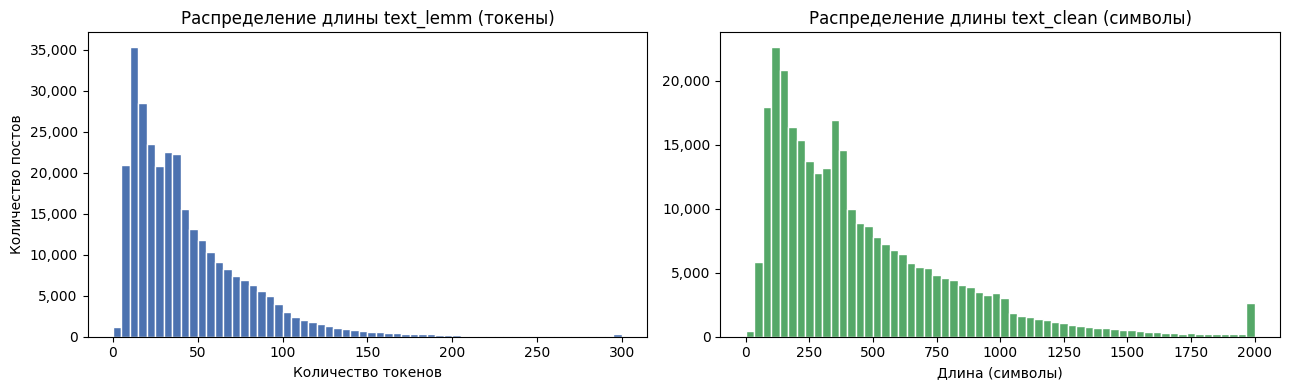

Медиана токенов после лемматизации: 34
Пустых text_lemm после обработки: 84 (0.03%)


In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df["lemm_len"] = df["text_lemm"].str.split().str.len()
df["clean_len"] = df["text_clean"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(
    df["lemm_len"].clip(upper=300), bins=60, color="#4C72B0", edgecolor="white"
)
axes[0].set_title("Распределение длины text_lemm (токены)")
axes[0].set_xlabel("Количество токенов")
axes[0].set_ylabel("Количество постов")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1].hist(
    df["clean_len"].clip(upper=2000), bins=60, color="#55A868", edgecolor="white"
)
axes[1].set_title("Распределение длины text_clean (символы)")
axes[1].set_xlabel("Длина (символы)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("figures/04_[preprocessing]_preprocessed_lengths.png", bbox_inches="tight")
plt.show()

print(f"Медиана токенов после лемматизации: {df['lemm_len'].median():.0f}")

empty_lemm = (df["text_lemm"].str.strip() == "").sum()
print(
    f"Пустых text_lemm после обработки: {empty_lemm:,} ({empty_lemm / len(df) * 100:.2f}%)"
)

In [12]:
preprocessed_dataset_path = "data/posts_preprocessed.parquet"

output_cols = [
    "id_post",
    "channel_name",
    "post_date",
    "text_clean",
    "text_lemm",
    "views",
]
df[output_cols].to_parquet(preprocessed_dataset_path, engine="fastparquet", index=False)

print(f"Сохранено: {preprocessed_dataset_path}")
print(f"Записей: {len(df):,}")
print(f"Колонки: {output_cols}")

Сохранено: data/posts_preprocessed.parquet
Записей: 300,000
Колонки: ['id_post', 'channel_name', 'post_date', 'text_clean', 'text_lemm', 'views']
